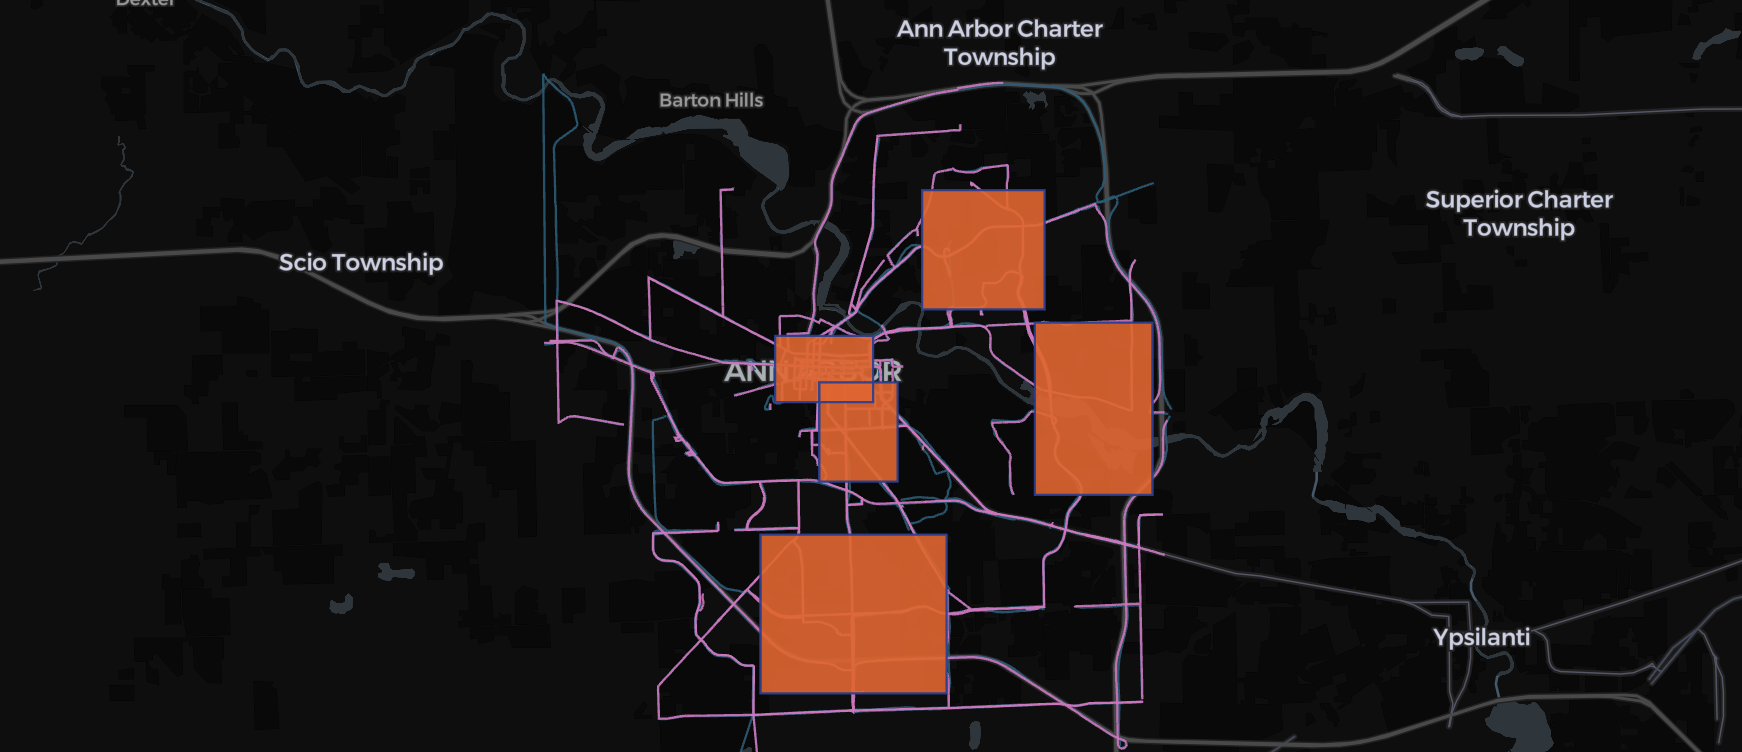

# Fleet Geofence Pipeline — End-to-End on Wherobots

**What the picture above is.** That's the endpoint of this pipeline:
the five delivery geofences laid over Ann Arbor, with the map-matched
vehicle routes (pink) overlaid on the OSM road network. Each orange
rectangle is a geofence where the fleet spent measurable time; the
surrounding track ink is the actual driven path once the raw GPS has
been snapped to roads. Everything that follows — the dwell-time table,
the zone rollup, the exported CSV/GeoJSON — is derived from this
same set of tagged pings.

A four-stage pipeline a logistics or last-mile delivery operator can run
nightly over a day's telemetry:

1. **Ingest** raw GPS traces from S3 (one row per ping).
2. **Map-match** each vehicle trip to the OSM road network so noisy GPS
   snaps onto the roads actually driven.
3. **Detect zone transitions** — for each ping, which delivery geofence does
   it fall in, and where does the zone change?
4. **Calculate dwell times** per (vehicle, trip, zone visit) — the time the
   truck actually spent inside each delivery zone.

## What you can do with the output

Dwell time per zone is the raw material for a lot of downstream
decisions the operator would otherwise be making on gut feel:

- **Driver dispatch & routing.** Zones with consistently long dwells
  need more time budgeted per stop; zones with short dwells can absorb
  denser route stacks. Feed the median dwell back into the routing
  engine's service-time parameter.
- **Customer / contract billing.** If the contract bills for
  "time-on-site," per-visit dwell is the source of truth. Total
  dwell-hours per zone rolls straight into the monthly invoice.
- **SLA monitoring.** Compare each visit's dwell against the zone's
  target service window. Visits in the long tail flag accounts that
  are routinely blowing through SLA — before the customer notices.
- **Geofence tuning.** If trajectories repeatedly clip a zone edge or
  dwell *just outside* a polygon, the fence is drawn wrong. Re-run
  the pipeline with adjusted polygons and watch the `IN_TRANSIT`
  share drop.
- **Coverage gaps & new-site candidates.** Zones with zero visits are
  under-served or the wrong shape. Conversely, dense dwell clusters
  *outside* any defined zone are candidates for new geofences — often
  the tell for a micro-DC, cross-dock, or driver rest stop that
  doesn't exist yet.
- **Driver payroll allocation.** Attribute each driver's paid hours
  to specific zones / contracts based on where they actually spent
  the time, not where the route said they would.
- **Capacity & fleet sizing.** Total dwell-hours per zone ÷ vehicles
  that touched it gives you a utilization number per geofence. Zones
  near saturation get additional trucks at the next planning cycle.
- **Contract renewal pricing.** Next year's quote stops being a
  guess — it's priced against a year of observed per-zone dwell
  distributions.

**Data.** This notebook runs against Wherobots' public sample data:
- `s3://wherobots-examples/data/VED_171101_week.csv` — one week of the
  [Vehicle Energy Dataset](https://github.com/gsoh/VED) (Ann Arbor, MI).
- `s3://wherobots-examples/data/osm_AnnArbor_large.xml` — OSM road network
  for the same region.
- Five hand-drawn delivery geofences across Ann Arbor (downtown, UM Central,
  UM North / Tech, South Industrial, East Commercial) defined inline.

## 1. Setup

In [ ]:
from sedona.spark import *
from wherobots import matcher
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number, lit
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

config = SedonaContext.builder().getOrCreate()
sedona = SedonaContext.create(config)

## 2. Stage 1 — Ingest GPS Traces from S3

Load the raw VED CSV and keep only the columns the pipeline needs. Each
row is a single GPS ping timestamped in milliseconds since epoch (relative
within the dataset).

In [ ]:
GPS_S3_PATH = "s3://wherobots-examples/data/VED_171101_week.csv"

raw_gps_df = (
    sedona.read
    .csv(GPS_S3_PATH, header=True, inferSchema=True)
    .selectExpr(
        "VehId            AS vehicle_id",
        "Trip             AS trip_id",
        "`Timestamp(ms)`  AS ts_ms",
        "`Latitude[deg]`  AS lat",
        "`Longitude[deg]` AS lon",
    )
)

print(f"Raw GPS pings ingested: {raw_gps_df.count():,}")
raw_gps_df.show(5, truncate=False)

## 3. Stage 2 — Build Trip LineStrings and Map-Match

Aggregate GPS pings per `(vehicle_id, trip_id)` into a LineString, keep a
representative subset of trips (the VED file has thousands), load the Ann
Arbor OSM road network, and call `matcher.match` to snap each trip onto
the actual road geometry.

In [ ]:
TRIP_LIMIT = 100

raw_gps_df.createOrReplaceTempView("pings_raw")

# Build trip LineStrings entirely in Sedona SQL — avoids the
# per-row Python<->JVM serialization cost of a PySpark UDF.
trips_df = sedona.sql("""
    SELECT
        vehicle_id,
        trip_id,
        ST_MakeLine(
            TRANSFORM(
                array_sort(collect_list(struct(ts_ms, lon, lat))),
                r -> ST_Point(r.lon, r.lat)
            )
        ) AS geometry
    FROM pings_raw
    GROUP BY vehicle_id, trip_id
""")

ids_window = Window.partitionBy(lit(1)).orderBy("vehicle_id", "trip_id")
trips_df = (
    trips_df
    .withColumn("ids", row_number().over(ids_window) - 1)
    .filter(col("ids") < TRIP_LIMIT)
    .select("ids", "vehicle_id", "trip_id", "geometry")
    .cache()
)

print(f"Trips prepared for map matching: {trips_df.count()}")
trips_df.select("ids", "vehicle_id", "trip_id").show(5, truncate=False)

In [ ]:
ROADS_S3_PATH = "s3://wherobots-examples/data/osm_AnnArbor_large.xml"

roads_df = matcher.load_osm(ROADS_S3_PATH, "[car]").cache()
print(f"Road segments loaded: {roads_df.count():,}")

# Map matching tolerances — tune for GPS noise level
sedona.conf.set("wherobots.tools.mm.maxdist",     "100")
sedona.conf.set("wherobots.tools.mm.maxdistinit", "100")
sedona.conf.set("wherobots.tools.mm.obsnoise",    "40")

matched_df = matcher.match(roads_df, trips_df, "geometry", "geometry").cache()
print(f"Trips successfully map-matched: {matched_df.count()}")
matched_df.select("ids").show(5, truncate=False)

## 4. Stage 3 — Define Delivery Geofences

Five zones covering the main commercial / institutional clusters the fleet
services. In a live system these come from the routing platform or CRM; here
we declare them inline so the demo is self-contained.

In [ ]:
# (zone_name, zone_type, min_lon, min_lat, max_lon, max_lat)
delivery_zones = [
    ("Downtown Ann Arbor",  "retail",      -83.755, 42.276, -83.735, 42.286),
    ("UM Central Campus",   "institutional",-83.746, 42.264, -83.730, 42.279),
    ("UM North / Tech",     "institutional",-83.725, 42.290, -83.700, 42.308),
    ("South Industrial",    "industrial",  -83.758, 42.232, -83.720, 42.256),
    ("East Commercial",     "retail",      -83.702, 42.262, -83.678, 42.288),
]

zone_schema = StructType([
    StructField("zone_name", StringType()),
    StructField("zone_type", StringType()),
    StructField("min_lon",   DoubleType()),
    StructField("min_lat",   DoubleType()),
    StructField("max_lon",   DoubleType()),
    StructField("max_lat",   DoubleType()),
])

zones_df = sedona.createDataFrame(delivery_zones, zone_schema) \
    .withColumn(
        "geometry",
        expr("ST_MakeEnvelope(min_lon, min_lat, max_lon, max_lat, 4326)")
    )

zones_df.createOrReplaceTempView("delivery_zones")
zones_df.select("zone_name", "zone_type",
                expr("ROUND(ST_Area(geometry) * 111 * 111, 2) AS approx_area_sq_km")) \
         .show(truncate=False)

## 5. Stage 3 (cont.) — Tag Pings and Detect Zone Transitions

Point-in-polygon each ping against the zones to attach a `zone_name`, then
use `LAG()` + a running sum to group consecutive same-zone pings into
*visits*. A visit ends when the next ping is in a different zone (or out
of all zones — we label that `IN_TRANSIT`).

In [ ]:
# Limit the ping set to the same 100 trips used for map matching so the
# dwell-time analysis aligns with the matched routes.
trip_keys_df = trips_df.select("vehicle_id", "trip_id")
pings_in_scope = raw_gps_df.join(trip_keys_df, ["vehicle_id", "trip_id"])
pings_in_scope.createOrReplaceTempView("pings")

# BROADCAST(z): zones is a 5-row reference table, so ship it to every
# executor and stream pings through — no shuffle of the large ping side.
tagged_sql = """
    SELECT /*+ BROADCAST(z) */
        p.vehicle_id,
        p.trip_id,
        p.ts_ms,
        p.lat,
        p.lon,
        COALESCE(z.zone_name, 'IN_TRANSIT') AS zone_name,
        z.zone_type
    FROM pings p
    LEFT JOIN delivery_zones z
      ON ST_Contains(z.geometry, ST_Point(p.lon, p.lat))
"""
tagged_df = sedona.sql(tagged_sql).cache()
tagged_df.createOrReplaceTempView("tagged_pings")

transitions_sql = """
    WITH with_prev AS (
        SELECT
            vehicle_id, trip_id, ts_ms, zone_name, zone_type,
            LAG(zone_name) OVER (
                PARTITION BY vehicle_id, trip_id
                ORDER BY ts_ms
            ) AS prev_zone
        FROM tagged_pings
    ),
    with_visit_id AS (
        SELECT
            vehicle_id, trip_id, ts_ms, zone_name, zone_type,
            SUM(CASE WHEN prev_zone IS NULL OR zone_name != prev_zone
                     THEN 1 ELSE 0 END)
              OVER (PARTITION BY vehicle_id, trip_id ORDER BY ts_ms) AS visit_id
        FROM with_prev
    )
    SELECT vehicle_id, trip_id, visit_id, zone_name, zone_type, ts_ms
    FROM with_visit_id
"""
visit_pings_df = sedona.sql(transitions_sql).cache()
visit_pings_df.createOrReplaceTempView("visit_pings")

# A transition = a visit boundary — show the first 20
sedona.sql("""
    SELECT vehicle_id, trip_id, visit_id, zone_name,
           MIN(ts_ms) AS enter_ts, MAX(ts_ms) AS exit_ts
    FROM visit_pings
    GROUP BY vehicle_id, trip_id, visit_id, zone_name
    ORDER BY vehicle_id, trip_id, visit_id
""").show(20, truncate=False)

## 6. Stage 4 — Dwell Time per Visit

Each contiguous run of same-zone pings is one visit; dwell = last timestamp
− first timestamp. Filter out `IN_TRANSIT` so we measure time actually
inside a delivery zone.

In [ ]:
visits_df = sedona.sql("""
    SELECT
        vehicle_id,
        trip_id,
        visit_id,
        zone_name,
        zone_type,
        MIN(ts_ms)                                        AS enter_ts,
        MAX(ts_ms)                                        AS exit_ts,
        COUNT(*)                                          AS ping_count,
        ROUND((MAX(ts_ms) - MIN(ts_ms)) / 1000.0, 1)      AS dwell_seconds
    FROM visit_pings
    WHERE zone_name != 'IN_TRANSIT'
    GROUP BY vehicle_id, trip_id, visit_id, zone_name, zone_type
    HAVING COUNT(*) >= 2
""").cache()
visits_df.createOrReplaceTempView("zone_visits")

print(f"In-zone visits detected: {visits_df.count()}")
visits_df.orderBy(col("dwell_seconds").desc()) \
         .show(10, truncate=False)

## 7. Fleet-Level Rollup

Aggregate visits up to the zone level so the logistics dashboard has one
row per delivery zone.

In [ ]:
zone_summary_df = sedona.sql("""
    SELECT
        zone_name,
        zone_type,
        COUNT(*)                                      AS visit_count,
        COUNT(DISTINCT vehicle_id)                    AS unique_vehicles,
        ROUND(AVG(dwell_seconds), 1)                  AS avg_dwell_seconds,
        ROUND(PERCENTILE(dwell_seconds, 0.5), 1)      AS median_dwell_seconds,
        ROUND(MAX(dwell_seconds), 1)                  AS max_dwell_seconds,
        ROUND(SUM(dwell_seconds) / 3600.0, 2)         AS total_dwell_hours
    FROM zone_visits
    GROUP BY zone_name, zone_type
    ORDER BY total_dwell_hours DESC
""")

zone_summary_df.show(truncate=False)

## 8. Export — Visits CSV + Zones GeoJSON

Two artifacts a downstream dashboard / BI tool would consume:
- `fleet_zone_visits.csv` — per-visit dwell records, joined to the zone
  polygon (`zone_geometry_wkt`) so the dashboard can render each visit
  against the zone without a secondary lookup.
- `fleet_delivery_zones.geojson` — zone polygons with their rollup stats
  baked into properties. Written via Sedona's native GeoJSON writer,
  which emits **newline-delimited Features** (one per line) rather than
  a single `FeatureCollection`. Consumers that require strict RFC 7946
  GeoJSON will need a small wrap step; tools like GDAL, DuckDB, and
  Mapbox GL JS accept NDJSON directly.

In [ ]:
# Visits CSV — per-visit dwell records with the zone polygon attached
# as WKT so the BI tool can render zone shapes without a secondary join.
visits_path = "/tmp/fleet_zone_visits.csv"

visits_with_geom_df = sedona.sql("""
    SELECT
        v.vehicle_id, v.trip_id, v.visit_id,
        v.zone_name, v.zone_type,
        v.enter_ts, v.exit_ts, v.ping_count, v.dwell_seconds,
        ST_AsText(z.geometry) AS zone_geometry_wkt
    FROM zone_visits v
    JOIN delivery_zones z USING (zone_name)
""")

visits_with_geom_df.orderBy("vehicle_id", "trip_id", "enter_ts") \
                   .toPandas() \
                   .to_csv(visits_path, index=False)
print(f"Wrote visits to {visits_path}")

# Zones GeoJSON — build a DataFrame with the zone geometry + rollup
# stats, then hand it to Sedona's native GeoJSON writer.
zone_features_df = sedona.sql("""
    SELECT
        z.zone_name,
        z.zone_type,
        COALESCE(s.visit_count, 0)         AS visit_count,
        COALESCE(s.unique_vehicles, 0)     AS unique_vehicles,
        COALESCE(s.avg_dwell_seconds, 0.0) AS avg_dwell_seconds,
        COALESCE(s.total_dwell_hours, 0.0) AS total_dwell_hours,
        z.geometry
    FROM delivery_zones z
    LEFT JOIN (
        SELECT
            zone_name,
            COUNT(*)                              AS visit_count,
            COUNT(DISTINCT vehicle_id)            AS unique_vehicles,
            ROUND(AVG(dwell_seconds), 1)          AS avg_dwell_seconds,
            ROUND(SUM(dwell_seconds) / 3600.0, 2) AS total_dwell_hours
        FROM zone_visits
        GROUP BY zone_name
    ) s ON z.zone_name = s.zone_name
""")

# Sedona's GeoJSON writer produces a directory of part files with
# newline-delimited Features. coalesce(1) keeps it to a single part
# since we only have ~5 zones.
geojson_path = "/tmp/fleet_delivery_zones.geojson"
zone_features_df.coalesce(1) \
                .write.format("geojson").mode("overwrite") \
                .save(geojson_path)
print(f"Wrote {zone_features_df.count()} zones to {geojson_path}/")

## 9. Preview on a Map

Overlay the delivery zones, the matched routes, and the raw GPS points
for a quick visual sanity check.

In [ ]:
viz = SedonaKepler.create_map()
SedonaKepler.add_df(viz, zones_df.select("zone_name", "zone_type", "geometry"),
                    name="Delivery Zones")
SedonaKepler.add_df(viz, matched_df.selectExpr("matched_points AS geometry", "ids AS trip_id"),
                    name="Matched Routes")
SedonaKepler.add_df(viz, trips_df.select("vehicle_id", "trip_id", "geometry"),
                    name="Observed Tracks")
viz